# NSL-KDD NID preprocessing and ML models
  
  This notebook contains the steps involved in preprocessing and break down the process into small milestones and we will apply some models and gonna evaluate the results
  
 ## The are steps involved in this process :
    
    1. Import libraries

    2. Load the dataset

    3. Clean the data

    4. Exploratory Data Analysis (EDA)

    5. Encode categorical features

    6. Scale features

    7. Split into train/test

    8. Train models

    9. Evaluate and compare

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step-1 Importing Modules

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Step-2 Load datasets

In [3]:

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'
]

train_df = pd.read_csv("/content/drive/MyDrive/nsl-kdd/KDDTrain+.txt", header=None, names=columns)
test_df = pd.read_csv("/content/drive/MyDrive/nsl-kdd/KDDTest+.txt", header=None, names=columns)
print(train_df.head())
print(test_df.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

## Step-3 Clean Data
Here we check the dulicates in the DataSet and remove it. We inspect the is there any nullValue present, if it is present we will drop the row

In [4]:
print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())

# train_df.dropna(inplace=True)
# test_df.dropna(inplace=True)

0
0


In [5]:
train_before=train_df.shape[0]
test_before=test_df.shape[0]

train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

train_after=train_df.shape[0]
test_after=test_df.shape[0]

print("difference after clearing duplicates in train = ",train_before-train_after)
print("difference after clearing duplicates in test = ",test_before-test_after)


difference after clearing duplicates in train =  0
difference after clearing duplicates in test =  0


## Creating Binary Target column
 The NSL-KDD dataset has a label column with values like "normal" or "neptune", "smurf", etc.
    
  We want a binary target:

  0 → Normal traffic

  1 → Any Attack

In [6]:
train_df["attack_binary"]=train_df["label"].apply(lambda x: 0 if x=="normal" else 1)
test_df["attack_binary"] = test_df["label"].apply(lambda x : 0 if x=="normal" else 1)

print(train_df["attack_binary"].value_counts())
print(test_df["attack_binary"].value_counts())

attack_binary
0    67343
1    58630
Name: count, dtype: int64
attack_binary
1    12833
0     9711
Name: count, dtype: int64


## Step-4 Exploratory Data Analysis (EDA)

   The first simple step we are gonna do is plotting hopw many attacks and normal samples we have

/tmp/ipython-input-1068147781.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="attack_binary",palette="colorblind",data=train_df,legend=False)


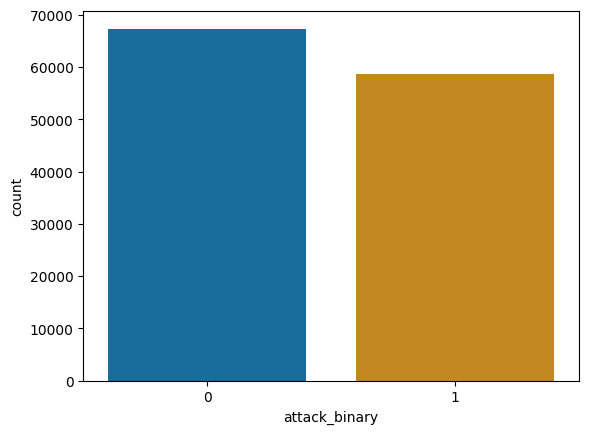

In [7]:
# for train_data

sns.countplot(x="attack_binary",palette="colorblind",data=train_df,legend=False)
# or we can give as x=train_df["attack_binnary"]
plt.title="Attack vs Normal"
plt.show()

/tmp/ipython-input-212589334.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="attack_binary",palette="colorblind",data=test_df,legend=False)


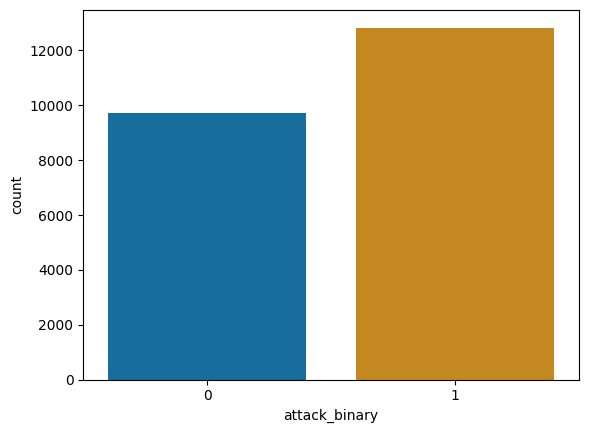

In [8]:
# for test data

sns.countplot(x="attack_binary",palette="colorblind",data=test_df,legend=False)
plt.title="Attack vs Normal"
plt.show()


## Step-5 Encoding Categorial features

 Here, I used label encoding for service feature where as one hot encoding for protocol_type and flags.

 Why I used label encoding for service feature is it has 60+ categories if we use onehot encoder it would add 60plus extra columns.

> Note : Label  encoding is only for decision trees like random forest
         where as for linear regression ,logistic regression, neural network one hot encoding suits well because even though it consumes large memory it wont affect the prediction or make wrong assumptions by assuming connection between numbers because it only takes Zeros and Ones which are completely independent.



In [44]:
from sklearn.preprocessing import LabelEncoder

# Label encode 'service'
le = LabelEncoder()
train_df['service'] = le.fit_transform(train_df['service'])

# One-hot encode protocol_type and flag
train_df = pd.get_dummies(train_df, columns=['protocol_type', 'flag'])


In [9]:
from sklearn.preprocessing import LabelEncoder

# Label encode 'service'
le = LabelEncoder()
test_df['service'] = le.fit_transform(test_df['service'])

# One-hot encode protocol_type and flag
test_df = pd.get_dummies(test_df, columns=['protocol_type', 'flag'])


## Step-6 Scaling Features

Feature scaling / normalization :

  1. Many features (like duration, src_bytes, dst_bytes) have huge ranges.

    Example: src_bytes might be in the thousands, while land is just 0/1.

  2. If we don’t scale, models (especially distance-based ones like KNN, SVM, Neural Nets) will give too much importance to large-range features.

  3. We can use MinMaxScaler or StandardScaler for scaling the feature  




---



### why it's need?

 Imagine you’re training a model that has to look at two features:

src_bytes (range: 0–5000)

land (range: 0–1)

Suppose the model is distance-based (like KNN) or gradient-based (like Neural Nets).

Example with KNN (distance-based model)

KNN predicts by finding the closest neighbors.

Distance formula:


>𝑑=(𝑥1−𝑦1)2+(𝑥2−𝑦2)2

Here, feature values matter directly.

If src_bytes changes from 1000 → 2000 (difference = 1000),

and land changes from 0 → 1 (difference = 1),

the distance is mostly determined by src_bytes, because 1000 is way bigger than 1.
So the model ignores land almost completely.

Example with Neural Network (gradient-based model)

Neural nets adjust weights using gradients.

A feature with large values (like 5000) produces larger gradients when multiplied by weights.

A feature with small values (like 0 or 1) contributes almost nothing.
So the network ends up giving unfair importance to high-range features.

---
### In short:

High-range features dominate the learning process.

Low-range features (even if important!) get ignored.

In [10]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Select numeric columns to scale
numeric_cols = ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'hot',
                'num_failed_logins', 'count', 'srv_count', 'serror_rate',
                'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
                'diff_srv_rate', 'srv_diff_host_rate']  # (example: adjust as per your df)

# Fit and transform only numeric columns
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_df[numeric_cols] = scaler.fit_transform(test_df[numeric_cols])


## Step 6 Split into train/test

When you build a model, you want to check if it’s actually learning patterns or just memorizing the data.

  1. Training set → used to teach the model.

  2. Testing set → used to evaluate how well the model performs on unseen data.

If you trained and tested on the same data, the model might look perfect but actually be useless in real-world situations.  


In [12]:
from sklearn.model_selection import train_test_split

# Suppose your target column is 'attack_binary'
X = train_df.drop('attack_binary', axis=1)   # all features except target
y = train_df['attack_binary']                # target column


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
